# Finetuning with PyTorch

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

import numpy as np

In [14]:
device_str = "cpu"
if torch.cuda.is_available():
    device_str = "cuda:0"
elif torch.backends.mps.is_available():
    device_str = "mps"
device = torch.device(device_str)
device

device(type='cuda', index=0)

In [15]:
data_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.size(0) == 1 else x),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        transforms.Resize(size=224, max_size=225),
        transforms.CenterCrop((224, 224)),
    ]
)

full_dataset = torchvision.datasets.Caltech101(
    root="./data/Caltech101",
    target_type="category",
    # target_type="annotation",
    download=True,
    transform=data_transform,
)

# Split the dataset into train and test sets
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Files already downloaded and verified
Train dataset size: 6941
Test dataset size: 1736


In [16]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
	batch_size=batch_size, 
	shuffle=True, 
	num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
	batch_size=batch_size, 
	shuffle=False, 
	num_workers=2,
)

classes = full_dataset.categories
classes

['Faces',
 'Faces_easy',
 'Leopards',
 'Motorbikes',
 'accordion',
 'airplanes',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooster',
 'saxophone',
 'sc

In [17]:
len(classes)

101

In [18]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([91,  2, 36, 98])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([ 1, 90,  5, 97])


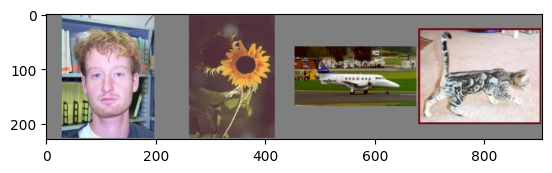

Faces_easy sunflower  airplanes  wild_cat  


In [19]:


# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:10s}' for j in range(batch_size)))

# Define a Loss function and optimizer

# Train

In [20]:
def train(net, train_loader, criterion, optimizer, device, epochs=2):
    print_every_n_batch = (len(train_loader) / batch_size) // 10
    if print_every_n_batch == 0:
        print_every_n_batch = 1
    net.to(device)
    for epoch in range(epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(train_loader):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # Move inputs and labels to the device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            # print(f"Inputs: {inputs.shape = }", flush=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % print_every_n_batch == 0 and i:
                print(
                    f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_every_n_batch:.3f}"
                )
                running_loss = 0.0

    print("Finished Training")


def evaluate_model(net, test_loader, device):
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in test_loader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            # calculate outputs by running images through the network
            outputs = net(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total

    # Compute precision, recall, and f1-score for each class
    from sklearn.metrics import precision_recall_fscore_support

    precision, recall, f1score, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average="weighted"
    )

    print(f"Accuracy of the network on the {total} test images: {accuracy:.2f}%")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"Weighted F1-score: {f1score:.4f}")

    return accuracy, precision, recall, f1score

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


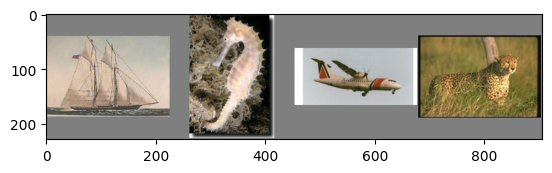

GroundTruth:
 schooner   sea_horse  airplanes  Leopards  


In [21]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print("GroundTruth:\n", " ".join(f"{classes[labels[j]]:10s}" for j in range(4)))

# Model

In [22]:
# https://pytorch.org/vision/stable/models.html
def get_pretrained_net():
    resnet = torchvision.models.resnet18(pretrained=True)
    resnet.train()

    resnet.fc = torch.nn.Linear(resnet.fc.in_features, len(classes))
    torch.nn.init.xavier_uniform_(resnet.fc.weight)

    return resnet

pretrained_net = get_pretrained_net()
pretrained_net

/home/ezalos/42/Notebooks2Teach/venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ezalos/42/Notebooks2Teach/venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
criterion = nn.CrossEntropyLoss()
params_to_update_1 = []
params_to_update_2 = []
params_to_update_3 = []

for name, param in pretrained_net.named_parameters():
    if name.startswith("fc"):
        param.requires_grad = True
        params_to_update_1.append(param)
    elif name.startswith("layer4"):
        param.requires_grad = True
        params_to_update_2.append(param)
    elif name.startswith("layer"):
        param.requires_grad = True
        params_to_update_3.append(param)
    else:
        param.requires_grad = False

optimizer = torch.optim.SGD(
    [
        {"params": params_to_update_1, "lr": 1e-3},
        {"params": params_to_update_2, "lr": 5e-4},
        {"params": params_to_update_3, "lr": 1e-4},
    ],
    momentum=0.9,
)

In [24]:
model_path = "./data/caltech_finetuned_resnet18.pth"
model = pretrained_net
NB_EPOCHS = 3

if True:
    train(model, train_loader, criterion, optimizer, device, epochs=NB_EPOCHS)
    torch.save(model.state_dict(), model_path)
else:
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    
evaluate_model(model, test_loader, device)

[1,    44] loss: 4.623
[1,    87] loss: 3.604
[1,   130] loss: 3.153
[1,   173] loss: 2.910
[1,   216] loss: 2.319
[1,   259] loss: 2.628
[1,   302] loss: 2.483
[1,   345] loss: 2.351
[1,   388] loss: 2.079
[1,   431] loss: 1.977
[1,   474] loss: 1.704
[1,   517] loss: 1.618
[1,   560] loss: 1.582
[1,   603] loss: 1.395
[1,   646] loss: 1.764
[1,   689] loss: 1.710
[1,   732] loss: 1.306
[1,   775] loss: 1.235
[1,   818] loss: 1.082
[1,   861] loss: 1.163
[1,   904] loss: 1.026
[1,   947] loss: 1.016
[1,   990] loss: 1.137
[1,  1033] loss: 0.979
[1,  1076] loss: 0.937
[1,  1119] loss: 0.888
[1,  1162] loss: 0.836
[1,  1205] loss: 0.956
[1,  1248] loss: 0.933
[1,  1291] loss: 0.997
[1,  1334] loss: 0.800
[1,  1377] loss: 0.683
[1,  1420] loss: 0.762
[1,  1463] loss: 0.939
[1,  1506] loss: 0.669
[1,  1549] loss: 0.615
[1,  1592] loss: 0.769
[1,  1635] loss: 0.663
[1,  1678] loss: 0.786
[1,  1721] loss: 0.630
[2,    44] loss: 0.567
[2,    87] loss: 0.513
[2,   130] loss: 0.391
[2,   173] 

(92.97235023041475, 0.9340198097544856, 0.9297235023041475, 0.928756561923632)